<img src="./src/LogoUTNNegro.png" align="right" width="150">

#### Teoría de los Circuitos 2

# Trabajo Semanal 0
#### Renzo Villani

### Consignas

Sea el siguiente circuito:
<center><img src="./src/img8_TS0.png"></center>


1.  Obtener la función transferencia $\frac{V2}{V1}$   módulo , fase y diagrama de polos y ceros.
2.  Proponga una norma de frecuencia e impedancia  de forma tal de llegar a una **transferencia normalizada**.
3.  Simule la **transferencia normalizada** en *Python*.
4.  Simule la red en *LTspice* y obtenga su respuesta en frecuencia.
5.  ¿Qué tipo de filtro es ? Analizar el caso del MF-103  ¿Utiliza la misma red?

### Punto 1

Obtengo la trasferencia a partir de igualar los dos divisores resistivos en las entradas del amplificador operarional. A patir de ahí es un trabajo algebráico.

<center><img src="./src/img1_TS0.png"></center>

La función transferencia resultante es:
### <center>$T(s)=\frac{s-\frac{R_2}{CR_1R_3}}{s+\frac{R_2}{CR_1R_3}}$</center>



Para a calcular el módulo y la fase hay que obtener la expresión en función de $\omega$:

### <center>$T(\omega) = T(s)|_{s=j\omega} = \frac{j{\omega}CR_1R_3-R_2}{j{\omega}CR_1R_3-R_2}$</center>

Separo la expresión en módulo y fase, y calculo ambos por separado.
<center><img src="./src/img2_TS0.png"></center>

Módulo:
### <center>$T(\omega) = \sqrt{\frac{({\omega}CR_1R_3)²+R_2²}{({\omega}CR_1R_3)²+R_1²}}$</center>

Fase:
### <center>$\theta(\omega) = arctg(\frac{{\omega}CR_1R_3}{R_2}) - arctg(\frac{{\omega}CR_1R_3}{R_1})$</center>

Para hacer los diagramas de bode voy a asignar valores arbitrarios a los componentes. De paso tomo la condición $(R_1 = R_2)$ para obtener un pasa todo prolijo.

$R_1=R_2=1K\Omega$

$R_3=10K\Omega$

$C=100nF$

<center><img src="./src/img3_TS0.png"></center>

### Punto 2

Para normalizar en frecuencia hay que cumplir con la condición: $\omega_o = 1$.

Para ello hay que hacer el cambio de variable: $s = S*\omega_o$.

<center><img src="./src/img4_TS0.png"></center>

Para normalizar en Z elijo una norma de $\Omega_z = R_1$ y obtengo los valores normalizados de cada componente bajo dicha condición.
<center><img src="./src/img5_TS0.png"></center>

La transferencia en función de los parámetros normalizados nos queda:
### <center>$T(S) = \frac{S-R_2''}{S+1}$</center>

Para el caso partircular $(R_1 = R_2)$  la transferencia resulta: 
### <center>$T(S) = \frac{S-1}{S+1}$</center>

### Punto 3

Simulo en *Python* la red normalizada. Cumpliendo la condición $(R_1 = R_2)$.

In [1]:
# Importo las librerías para trabajar de acá en adelante.

# Librerías externas NumPy, SciPy y Matplotlib
from scipy.signal import TransferFunction
from scipy import signal as sig
import matplotlib.pyplot as plt
import numpy as np

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

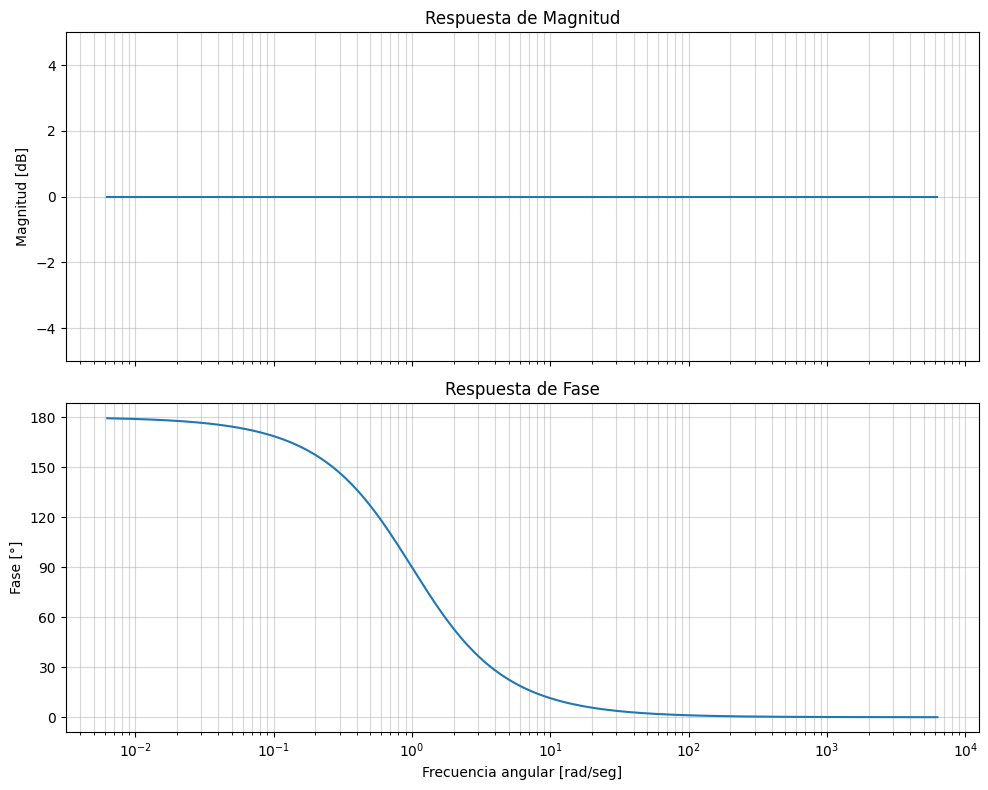

(1, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

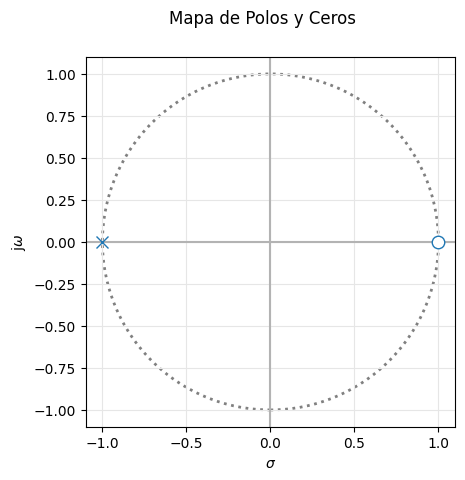

In [2]:
# Valores de los componentes previo a normalizar.
R1 = 1000
R2 = 1000
R3 = 10000
C = 100 * 1e-9

# Valores de los componentes normalizados (normalización en Z)
R1N = R1/R1
R2N = R2/R1
R3N = R3/R1

# Transferencia de la red original
# num = np.array([C*R1*R3, -R2])
# den = np.array([C*R1*R3, +R1])

# Estas etapas están diseñadas para desplazar la fase de la señal de entrada sin alterar su amplitud. Al combinar estas 12 señales desfasadas con la señal original ("Dry"), se producen las interferencias que crean los 6 valles (notches) característicos en la respuesta de frecuencia del modo de 12 etapas.Transferencia de la red normalizada (normalización en frecuencia)
num = np.array([1, -R2/R1])
den = np.array([1, 1])

T1 = TransferFunction(num, den)
#display(T1)

f = np.logspace(-3, 3, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T1,w)

plt.close('all')

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Gráfico de Magnitud
ax_mag.semilogx(w, mag)
ax_mag.set_title('Respuesta de Magnitud')
ax_mag.set_ylabel('Magnitud [dB]')
ax_mag.grid(True, which="both", ls="-", alpha=0.5)


# Gráfico de Fase
ticks = np.arange(0, 181, 30)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia angular [rad/seg]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

# Ajuste de límites para que se vea como en la captura
ax_mag.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

#bodePlot(T1, fig_id=1)
pzmap(T1)

Los resultados son los esperados de la configuración del filtro dada.

### Punto 4

Simulo circuitalmente la red en *LTspice* para obtener la respuesta en frecuencia.

<center><img src="./src/img6_TS0.jpeg" width="600"></center>

<center><img src="./src/img7_TS0.jpeg" width="900"></center>

Estos resultados tienen notorias diferencias con los esperados.

Respecto al módulo, este empieza a decaer a partir de los MHz. Esta diferencia se puede explicar a partir del limitado de ancho de banda que tienen los amplificadores operacionales.

Con la fase la historia es distinta:
El comportamoento es completamente fuera de lo esperado.


Adjunto la simulación numérica para comparar:

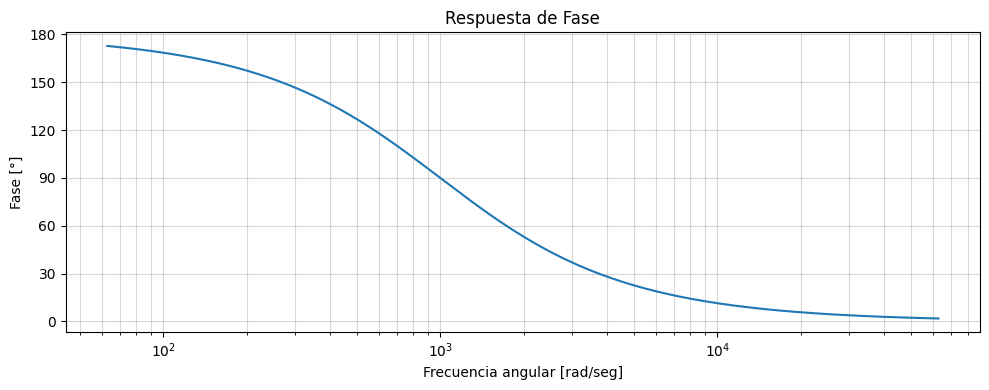

In [3]:
num = np.array([C*R1*R3, -R2])
den = np.array([C*R1*R3, +R1])
                
T1 = TransferFunction(num, den)

f = np.logspace(1, 4, 1000)

w = 2*np.pi*f

w, mag, phase = sig.bode(T1,w)

fig, (ax_phase) = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# --- Gráfico de Fase ---
ticks = np.arange(0, 181, 30)
ax_phase.set_yticks(ticks)

ax_phase.semilogx(w, phase)
ax_phase.set_title('Respuesta de Fase')
ax_phase.set_ylabel('Fase [°]')
ax_phase.set_xlabel('Frecuencia angular [rad/seg]')
ax_phase.grid(True, which="both", ls="-", alpha=0.5)

# Ajuste de límites para que se vea como en la captura
ax_mag.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

Este es un comportamiento más acorde a la red. Aparte de tener la curva proria de un pasa todo de primer orden, se puede ver con presición como $\theta(\omega_o) = 90°$.

### Punto 5

El filtro en cuestión es un **pasa todo de primer orden** siempre y cuando se cumpla con la condición $R_1 = R_2$. Este tipo de filtros son muy útiles para corregir desfaces de etapas anteriores.

El término MF-103 se refiere principalmente al Moog Moogerfooger MF-103, un pedal de efectos analógico.

<center><img src="./src/img9_TS0.png" width="900"></center>

En el esquema se pueden ver varias estapas de filtro pasatodo.

Estas etapas tienen el objetivo de retardar la señal. Al combinar estas señales desfasadas con la señal original se producen interferencias y se crean valles.


### Conclusión

Esta actividad permitió afianzar conocimientos previos comparando simulaciones matemáticas ideales con circuitales, analizando las discrepancias que fueron producto de las consideraciones de cada método. Un ejemplo de estas consideraciones fue **tomar al amplificador operacional como ideal** para obtener la función transferencia (simulación matemática). Asimismo, fue posible observar una aplicación práctica de este filtro en un entorno profesional como el MF-103. El ejercicio resalta cómo la teoría fundamental se integra en diseños complejos.